<h5 style="background-color:#E9F7EF; margin-bottom:0px;padding:20px; color:#000; border:5px solid Green"> 
Objective :  To analyse the relationship between Sleeping patterns and Mood using data collected from 102 responses.
</h5>

### Importing necessary Libraries :

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### SECTION A: DATA UNDERSTANDING (Q1 - Q5)

##### Q1. Load the sleep survey dataset into a Pandas DataFrame and display the first 5 rows.

In [2]:
sleep_and_mood_df = pd.read_excel("C:/Users/nisha/Desktop/DSet/Sleep_and_Mood_Patterns_data.xlsx")
sleep_and_mood_df.head()

,Response_No,Name,Age_Group,Sleep_Duration,Bedtime_Range,Mood_Rating,Difficulty_falling_asleep,Sleep_Aids_Usage,Daily_Nap_Count,Morning_Refresh_Score,Pre_Sleep_Screen_Time_Category
0,1,Janhavi amin,15-18 years,6 to 8 hours,11:00 PM – 12:59 AM,3,No,no,0.0,4,more than 2 hours
1,2,Chitra chavan,19- 25 years,4 to 6 hours,11:00 PM – 12:59 AM,2,Yes,no,0.0,3,less than 1 hour
2,3,geeva,19- 25 years,4 to 6 hours,11:00 PM – 12:59 AM,3,Yes,no,0.0,2,more than 2 hours
3,4,Yashvi,19- 25 years,4 to 6 hours,After 1:00 AM,3,Yes,no,0.0,2,1 to 2 hours
4,5,Aarya,15-18 years,6 to 8 hours,After 1:00 AM,3,No,no,0.0,2,more than 2 hours


##### Q2: Total records and columns

In [3]:
sleep_and_mood_df.shape

(102, 11)

#### Q3: Data types and missing values.

In [5]:
sleep_and_mood_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Response_No                     102 non-null    int64  
 1   Name                            102 non-null    object 
 2   Age_Group                       102 non-null    object 
 3   Sleep_Duration                  102 non-null    object 
 4   Bedtime_Range                   102 non-null    object 
 5   Mood_Rating                     102 non-null    int64  
 6   Difficulty_falling_asleep       102 non-null    object 
 7   Sleep_Aids_Usage                102 non-null    object 
 8   Daily_Nap_Count                 101 non-null    float64
 9   Morning_Refresh_Score           102 non-null    int64  
 10  Pre_Sleep_Screen_Time_Category  102 non-null    object 
dtypes: float64(1), int64(3), object(7)
memory usage: 8.9+ KB


In [6]:
sleep_and_mood_df.isna().sum()

Response_No                       0
Name                              0
Age_Group                         0
Sleep_Duration                    0
Bedtime_Range                     0
Mood_Rating                       0
Difficulty_falling_asleep         0
Sleep_Aids_Usage                  0
Daily_Nap_Count                   1
Morning_Refresh_Score             0
Pre_Sleep_Screen_Time_Category    0
dtype: int64

#### Q4: Identify column types.

In [7]:
numerical_cols = sleep_and_mood_df.select_dtypes(include=['int64','float64']).columns
categorical_cols = sleep_and_mood_df.select_dtypes(include=['object']).columns

print("Numerical:", numerical_cols)
print("Categorical:", categorical_cols)

# Ordinal columns (example – depends on dataset)
ordinal_cols = ['Mood_Rating','Refreshment_Score','Sleep_Duration']

Numerical: Index(['Response_No', 'Mood_Rating', 'Daily_Nap_Count',
       'Morning_Refresh_Score'],
      dtype='object')
Categorical: Index(['Name', 'Age_Group', 'Sleep_Duration', 'Bedtime_Range',
       'Difficulty_falling_asleep', 'Sleep_Aids_Usage',
       'Pre_Sleep_Screen_Time_Category'],
      dtype='object')


#### Q5: All fields scale 

In [8]:
# 1: Unique age groups
sleep_and_mood_df['Age_Group'].unique()

array(['15-18 years', '19- 25 years', '26- 35 years', '35+ years'],
      dtype=object)

In [9]:
# 2: Sleep duration categories
sleep_and_mood_df['Sleep_Duration'].unique()

array(['6 to 8 hours', '4 to 6 hours', 'Less than 4 hours',
       'More than 8 hours'], dtype=object)

In [10]:
# 3: Bedtime ranges
sleep_and_mood_df['Bedtime_Range'].unique()

array(['11:00 PM – 12:59 AM', 'After 1:00 AM', 'Before 9:00 PM',
       '9:00 PM – 10:59 PM'], dtype=object)

In [11]:
# 4: Mood scale
sleep_and_mood_df['Mood_Rating'].unique()

array([3, 2, 5, 4], dtype=int64)

In [12]:
# 5: Morning Refreshment scale
sleep_and_mood_df['Morning_Refresh_Score'].unique()

array([4, 3, 2, 1, 5], dtype=int64)

### SECTION B: DESCRIPTIVE STATISTICS (Q6)

#### Q6: Calculating the following and presenting in table formate.
- Calculate the average refreshment score after waking up. 
- Find the most common sleep duration category. 
- Determine the most common bedtime range. 
- Calculate the percentage of respondents who have difficulty falling asleep. 
- Find the average number of naps taken per day. 
- Identify the most common duration of device usage before sleep. 
- Determine how many respondents use sleep aids.

In [13]:
# Calculate values
avg_mood = sleep_and_mood_df['Mood_Rating'].mean() 
avg_refresh = sleep_and_mood_df['Morning_Refresh_Score'].mean() 
common_sleep_duration = sleep_and_mood_df['Sleep_Duration'].mode()[0] 
common_bedtime = sleep_and_mood_df['Bedtime_Range'].mode()[0]         
difficulty_percent = (sleep_and_mood_df['Difficulty_falling_asleep'] == 'Yes').mean() * 100
avg_naps = sleep_and_mood_df['Daily_Nap_Count'].mean()
common_device_usage = sleep_and_mood_df['Pre_Sleep_Screen_Time_Category'].mode()[0]
sleep_aid_counts = sleep_and_mood_df['Sleep_Aids_Usage'].value_counts().to_dict()

# Create summary table
summary_table = pd.DataFrame({
    "Metric": [
        "Average Mood Rating",
        "Average Refreshment Score",
        "Most Common Sleep Duration",
        "Most Common Bedtime Range",
        "% With Difficulty Falling Asleep",
        "Average Naps Per Day",
        "Most Common Device Usage Before Bed",
        "Sleep Aid Usage Count"
    ],
    "Value": [
        round(avg_mood, 2),
        round(avg_refresh, 2),
        common_sleep_duration,
        common_bedtime,
        round(difficulty_percent, 2),
        round(avg_naps, 2),
        common_device_usage,
        sleep_aid_counts
    ]
})

summary_table

,Metric,Value
0,Average Mood Rating,4.07
1,Average Refreshment Score,3.73
2,Most Common Sleep Duration,6 to 8 hours
3,Most Common Bedtime Range,11:00 PM – 12:59 AM
4,% With Difficulty Falling Asleep,25.49
5,Average Naps Per Day,0.43
6,Most Common Device Usage Before Bed,more than 2 hours
7,Sleep Aid Usage Count,"{'no': 99, 'Yes': 3}"


### SECTION C: DATA FILTERING & CONDITIONS (Q7 -Q14)

#### Q7: Filter respondents who sleep less than 6 hours per night.

In [14]:
sleep_and_mood_df[sleep_and_mood_df['Sleep_Duration'] == '4 to 6 hours']

,Response_No,Name,Age_Group,Sleep_Duration,Bedtime_Range,Mood_Rating,Difficulty_falling_asleep,Sleep_Aids_Usage,Daily_Nap_Count,Morning_Refresh_Score,Pre_Sleep_Screen_Time_Category
1,2,Chitra chavan,19- 25 years,4 to 6 hours,11:00 PM – 12:59 AM,2,Yes,no,0.0,3,less than 1 hour
2,3,geeva,19- 25 years,4 to 6 hours,11:00 PM – 12:59 AM,3,Yes,no,0.0,2,more than 2 hours
3,4,Yashvi,19- 25 years,4 to 6 hours,After 1:00 AM,3,Yes,no,0.0,2,1 to 2 hours
5,6,Dakshina Pillai,19- 25 years,4 to 6 hours,11:00 PM – 12:59 AM,3,Yes,no,0.0,2,more than 2 hours
6,7,Shubham Mandadi,19- 25 years,4 to 6 hours,11:00 PM – 12:59 AM,5,Yes,Yes,2.0,2,more than 2 hours
11,12,Deepa,19- 25 years,4 to 6 hours,11:00 PM – 12:59 AM,3,Yes,no,1.0,3,1 to 2 hours
17,18,Tanishka Shinde,15-18 years,4 to 6 hours,After 1:00 AM,4,Yes,no,1.0,3,1 to 2 hours
19,20,Suzanne Alphonso,15-18 years,4 to 6 hours,After 1:00 AM,4,Yes,no,1.0,3,more than 2 hours
20,21,Sharwari kothawale,15-18 years,4 to 6 hours,11:00 PM – 12:59 AM,3,Yes,no,0.0,2,more than 2 hours
22,23,Chitra Chavan,15-18 years,4 to 6 hours,11:00 PM – 12:59 AM,4,Yes,no,0.0,1,less than 1 hour


#### Q8: Identify respondents who go to bed after 1:00 AM.

In [15]:
sleep_and_mood_df[sleep_and_mood_df['Bedtime_Range'] == 'After 1:00 AM']

,Response_No,Name,Age_Group,Sleep_Duration,Bedtime_Range,Mood_Rating,Difficulty_falling_asleep,Sleep_Aids_Usage,Daily_Nap_Count,Morning_Refresh_Score,Pre_Sleep_Screen_Time_Category
3,4,Yashvi,19- 25 years,4 to 6 hours,After 1:00 AM,3,Yes,no,0.0,2,1 to 2 hours
4,5,Aarya,15-18 years,6 to 8 hours,After 1:00 AM,3,No,no,0.0,2,more than 2 hours
13,14,tanishka,15-18 years,Less than 4 hours,After 1:00 AM,3,Yes,no,0.0,2,1 to 2 hours
17,18,Tanishka Shinde,15-18 years,4 to 6 hours,After 1:00 AM,4,Yes,no,1.0,3,1 to 2 hours
19,20,Suzanne Alphonso,15-18 years,4 to 6 hours,After 1:00 AM,4,Yes,no,1.0,3,more than 2 hours
24,25,Ismail Kumar,19- 25 years,6 to 8 hours,After 1:00 AM,3,No,no,0.0,2,more than 2 hours
32,33,Niki,15-18 years,6 to 8 hours,After 1:00 AM,4,Yes,no,1.0,4,more than 2 hours
35,36,Sakshii,19- 25 years,More than 8 hours,After 1:00 AM,4,No,no,0.0,4,more than 2 hours
37,38,Geeve,19- 25 years,More than 8 hours,After 1:00 AM,2,No,no,1.0,2,more than 2 hours
52,53,Ritesh,19- 25 years,More than 8 hours,After 1:00 AM,3,No,no,1.0,4,more than 2 hours


#### Q9: Filter respondents who report difficulty falling asleep.

In [16]:
sleep_and_mood_df[sleep_and_mood_df['Difficulty_falling_asleep'] == 'Yes']

,Response_No,Name,Age_Group,Sleep_Duration,Bedtime_Range,Mood_Rating,Difficulty_falling_asleep,Sleep_Aids_Usage,Daily_Nap_Count,Morning_Refresh_Score,Pre_Sleep_Screen_Time_Category
1,2,Chitra chavan,19- 25 years,4 to 6 hours,11:00 PM – 12:59 AM,2,Yes,no,0.0,3,less than 1 hour
2,3,geeva,19- 25 years,4 to 6 hours,11:00 PM – 12:59 AM,3,Yes,no,0.0,2,more than 2 hours
3,4,Yashvi,19- 25 years,4 to 6 hours,After 1:00 AM,3,Yes,no,0.0,2,1 to 2 hours
5,6,Dakshina Pillai,19- 25 years,4 to 6 hours,11:00 PM – 12:59 AM,3,Yes,no,0.0,2,more than 2 hours
6,7,Shubham Mandadi,19- 25 years,4 to 6 hours,11:00 PM – 12:59 AM,5,Yes,Yes,2.0,2,more than 2 hours
9,10,Anil Tandel,35+ years,6 to 8 hours,Before 9:00 PM,3,Yes,no,2.0,3,1 to 2 hours
11,12,Deepa,19- 25 years,4 to 6 hours,11:00 PM – 12:59 AM,3,Yes,no,1.0,3,1 to 2 hours
13,14,tanishka,15-18 years,Less than 4 hours,After 1:00 AM,3,Yes,no,0.0,2,1 to 2 hours
16,17,Sana,15-18 years,6 to 8 hours,11:00 PM – 12:59 AM,5,Yes,no,1.0,2,more than 2 hours
17,18,Tanishka Shinde,15-18 years,4 to 6 hours,After 1:00 AM,4,Yes,no,1.0,3,1 to 2 hours


#### Q10: Find respondents who use electronic devices for more than 2 hours before sleeping.

In [17]:
sleep_and_mood_df[sleep_and_mood_df['Pre_Sleep_Screen_Time_Category'] == 'more than 2 hours']

,Response_No,Name,Age_Group,Sleep_Duration,Bedtime_Range,Mood_Rating,Difficulty_falling_asleep,Sleep_Aids_Usage,Daily_Nap_Count,Morning_Refresh_Score,Pre_Sleep_Screen_Time_Category
0,1,Janhavi amin,15-18 years,6 to 8 hours,11:00 PM – 12:59 AM,3,No,no,0.0,4,more than 2 hours
2,3,geeva,19- 25 years,4 to 6 hours,11:00 PM – 12:59 AM,3,Yes,no,0.0,2,more than 2 hours
4,5,Aarya,15-18 years,6 to 8 hours,After 1:00 AM,3,No,no,0.0,2,more than 2 hours
5,6,Dakshina Pillai,19- 25 years,4 to 6 hours,11:00 PM – 12:59 AM,3,Yes,no,0.0,2,more than 2 hours
6,7,Shubham Mandadi,19- 25 years,4 to 6 hours,11:00 PM – 12:59 AM,5,Yes,Yes,2.0,2,more than 2 hours
...,...,...,...,...,...,...,...,...,...,...,...
96,97,Omkar desai,15-18 years,More than 8 hours,11:00 PM – 12:59 AM,4,No,no,0.0,4,more than 2 hours
97,98,Swati bhandari,26- 35 years,6 to 8 hours,9:00 PM – 10:59 PM,4,No,no,0.0,5,more than 2 hours
98,99,Hemant jha,26- 35 years,6 to 8 hours,9:00 PM – 10:59 PM,5,No,no,0.0,5,more than 2 hours
99,100,Karthik srinivasan,26- 35 years,More than 8 hours,11:00 PM – 12:59 AM,5,No,no,0.0,4,more than 2 hours


#### Q11. Identify respondents with mood rating less than or equal to 2.

In [18]:
sleep_and_mood_df[sleep_and_mood_df['Mood_Rating'] <= 2]

,Response_No,Name,Age_Group,Sleep_Duration,Bedtime_Range,Mood_Rating,Difficulty_falling_asleep,Sleep_Aids_Usage,Daily_Nap_Count,Morning_Refresh_Score,Pre_Sleep_Screen_Time_Category
1,2,Chitra chavan,19- 25 years,4 to 6 hours,11:00 PM – 12:59 AM,2,Yes,no,0.0,3,less than 1 hour
37,38,Geeve,19- 25 years,More than 8 hours,After 1:00 AM,2,No,no,1.0,2,more than 2 hours
49,50,Ravi,19- 25 years,6 to 8 hours,11:00 PM – 12:59 AM,2,No,no,0.0,2,more than 2 hours


#### Q12. Filter respondents who feel poorly refreshed (refreshment score ≤ 2).

In [19]:
sleep_and_mood_df[sleep_and_mood_df['Morning_Refresh_Score'] <= 2]

,Response_No,Name,Age_Group,Sleep_Duration,Bedtime_Range,Mood_Rating,Difficulty_falling_asleep,Sleep_Aids_Usage,Daily_Nap_Count,Morning_Refresh_Score,Pre_Sleep_Screen_Time_Category
2,3,geeva,19- 25 years,4 to 6 hours,11:00 PM – 12:59 AM,3,Yes,no,0.0,2,more than 2 hours
3,4,Yashvi,19- 25 years,4 to 6 hours,After 1:00 AM,3,Yes,no,0.0,2,1 to 2 hours
4,5,Aarya,15-18 years,6 to 8 hours,After 1:00 AM,3,No,no,0.0,2,more than 2 hours
5,6,Dakshina Pillai,19- 25 years,4 to 6 hours,11:00 PM – 12:59 AM,3,Yes,no,0.0,2,more than 2 hours
6,7,Shubham Mandadi,19- 25 years,4 to 6 hours,11:00 PM – 12:59 AM,5,Yes,Yes,2.0,2,more than 2 hours
13,14,tanishka,15-18 years,Less than 4 hours,After 1:00 AM,3,Yes,no,0.0,2,1 to 2 hours
16,17,Sana,15-18 years,6 to 8 hours,11:00 PM – 12:59 AM,5,Yes,no,1.0,2,more than 2 hours
20,21,Sharwari kothawale,15-18 years,4 to 6 hours,11:00 PM – 12:59 AM,3,Yes,no,0.0,2,more than 2 hours
22,23,Chitra Chavan,15-18 years,4 to 6 hours,11:00 PM – 12:59 AM,4,Yes,no,0.0,1,less than 1 hour
24,25,Ismail Kumar,19- 25 years,6 to 8 hours,After 1:00 AM,3,No,no,0.0,2,more than 2 hours


#### Q13. Identify respondents who take more than one nap per day. 

In [20]:
sleep_and_mood_df[sleep_and_mood_df['Daily_Nap_Count'] > 1]

,Response_No,Name,Age_Group,Sleep_Duration,Bedtime_Range,Mood_Rating,Difficulty_falling_asleep,Sleep_Aids_Usage,Daily_Nap_Count,Morning_Refresh_Score,Pre_Sleep_Screen_Time_Category
6,7,Shubham Mandadi,19- 25 years,4 to 6 hours,11:00 PM – 12:59 AM,5,Yes,Yes,2.0,2,more than 2 hours
9,10,Anil Tandel,35+ years,6 to 8 hours,Before 9:00 PM,3,Yes,no,2.0,3,1 to 2 hours
73,74,Sneha reddy,19- 25 years,6 to 8 hours,9:00 PM – 10:59 PM,3,No,no,2.0,3,more than 2 hours
93,94,Komal Dubey,19- 25 years,More than 8 hours,11:00 PM – 12:59 AM,5,No,no,2.0,5,1 to 2 hours
101,102,Sakshi rane,26- 35 years,More than 8 hours,11:00 PM – 12:59 AM,4,No,no,2.0,3,1 to 2 hours


#### Q14.  Filter respondents who use any form of sleep aid.

In [21]:
sleep_and_mood_df[sleep_and_mood_df['Sleep_Aids_Usage'] == 'Yes']

,Response_No,Name,Age_Group,Sleep_Duration,Bedtime_Range,Mood_Rating,Difficulty_falling_asleep,Sleep_Aids_Usage,Daily_Nap_Count,Morning_Refresh_Score,Pre_Sleep_Screen_Time_Category
6,7,Shubham Mandadi,19- 25 years,4 to 6 hours,11:00 PM – 12:59 AM,5,Yes,Yes,2.0,2,more than 2 hours
46,47,Josh,19- 25 years,6 to 8 hours,11:00 PM – 12:59 AM,4,No,Yes,0.0,3,more than 2 hours
56,57,Pranjal,19- 25 years,6 to 8 hours,11:00 PM – 12:59 AM,4,Yes,Yes,0.0,4,more than 2 hours


### SECTION D: GROUPING & AGGREGATION (Q15 - Q22)

#### Q15. Group respondents by age group and calculate average sleep duration.

In [22]:
sleep_and_mood_df.groupby('Age_Group')['Sleep_Duration'].value_counts()

Age_Group     Sleep_Duration   
15-18 years   6 to 8 hours          8
              4 to 6 hours          4
              Less than 4 hours     1
              More than 8 hours     1
19- 25 years  6 to 8 hours         29
              More than 8 hours    17
              4 to 6 hours         10
26- 35 years  More than 8 hours    12
              6 to 8 hours         10
35+ years     More than 8 hours     8
              6 to 8 hours          2
Name: count, dtype: int64

#### Q16. Group by bedtime category and calculate average mood rating. 

In [23]:
sleep_and_mood_df.groupby('Bedtime_Range')['Mood_Rating'].mean()

Bedtime_Range
11:00 PM – 12:59 AM    3.962264
9:00 PM – 10:59 PM     4.411765
After 1:00 AM          3.454545
Before 9:00 PM         4.250000
Name: Mood_Rating, dtype: float64

#### Q17. Calculate average refreshment score based on sleep duration.

In [24]:
sleep_and_mood_df.groupby('Sleep_Duration')['Morning_Refresh_Score'].mean()

Sleep_Duration
4 to 6 hours         2.785714
6 to 8 hours         3.714286
Less than 4 hours    2.000000
More than 8 hours    4.131579
Name: Morning_Refresh_Score, dtype: float64

#### Q18. Group by device usage before sleep and calculate average sleep quality.

In [25]:
sleep_and_mood_df.groupby('Pre_Sleep_Screen_Time_Category')['Morning_Refresh_Score'].mean()

Pre_Sleep_Screen_Time_Category
1 to 2 hours         3.863636
less than 1 hour     3.400000
more than 2 hours    3.689189
none                 5.000000
Name: Morning_Refresh_Score, dtype: float64

#### Q19. Count number of respondents by difficulty falling asleep (Yes/No).

In [26]:
sleep_and_mood_df['Difficulty_falling_asleep'].value_counts()

Difficulty_falling_asleep
No     76
Yes    26
Name: count, dtype: int64

#### Q20. Group by sleep aid usage and calculate average mood.

In [27]:
sleep_and_mood_df.groupby('Sleep_Aids_Usage')['Mood_Rating'].mean()

Sleep_Aids_Usage
Yes    4.333333
no     4.060606
Name: Mood_Rating, dtype: float64

#### Q21.Create a summary table showing age group vs average refreshment score.

In [28]:
sleep_and_mood_df.groupby('Age_Group')['Morning_Refresh_Score'].mean().reset_index()

,Age_Group,Morning_Refresh_Score
0,15-18 years,2.857143
1,19- 25 years,3.660714
2,26- 35 years,4.136364
3,35+ years,4.400000


#### Q22. Determine which bedtime category is associated with the lowest mood rating.

In [29]:
sleep_and_mood_df.groupby('Bedtime_Range')['Mood_Rating'].mean().sort_values()

Bedtime_Range
After 1:00 AM          3.454545
11:00 PM – 12:59 AM    3.962264
Before 9:00 PM         4.250000
9:00 PM – 10:59 PM     4.411765
Name: Mood_Rating, dtype: float64

### SECTION E: FEATURE ENGINEERING (Q23 - Q30)

#### Q23. Create a binary column indicating insufficient sleep (< 6 hours).

In [30]:
# here we havedone mapping (1 for <6 and 0 for >6) 
sleep_map = {
    'Less than 4 hours': 1,
    '4 to 6 hours': 1,
    '6 to 8 hours': 0,
    'More than 8 hours': 0
}

sleep_and_mood_df['Insufficient_Sleep'] = sleep_and_mood_df['Sleep_Duration'].map(sleep_map)

#### Q24. Encode difficulty falling asleep into numerical values.

In [31]:
sleep_and_mood_df['Difficulty_falling_asleep'] = sleep_and_mood_df['Difficulty_falling_asleep'].map({'Yes':1,'No':0})

#### Q25.	Convert mood ratings into categorical labels (Very Bad to Very Good).


In [32]:
def mood_label(x):
    if x == 1: return "Very Bad"
    elif x == 2: return "Bad"
    elif x == 3: return "Neutral"
    elif x == 4: return "Good"
    else: return "Very Good"

sleep_and_mood_df['Mood_Category'] = sleep_and_mood_df['Mood_Rating'].apply(mood_label)

#### Q26.	Create a sleep quality score using sleep duration and refreshment score.

In [33]:
# first we will Convert to Numeric Hours and create new field - Sleep_Hours
# then Create Sleep Quality Score

def convert_sleep(x):
    if x == 'Less than 4 hours':
        return 3
    elif x == '4 to 6 hours':
        return 5
    elif x == '6 to 8 hours':
        return 7
    elif x == 'More than 8 hours':
        return 9

sleep_and_mood_df['Sleep_Hours'] = sleep_and_mood_df['Sleep_Duration'].apply(convert_sleep)
sleep_and_mood_df['Sleep_Quality_Score'] = ( sleep_and_mood_df['Sleep_Hours'] * sleep_and_mood_df['Morning_Refresh_Score'])

#### Q27. Create a feature indicating high screen exposure before bed.

In [34]:
#High Exposure = ONLY "more than 2 hours" and which will be denoted as 1.
sleep_and_mood_df['High_Screen_Exposure'] = ( 
    sleep_and_mood_df['Pre_Sleep_Screen_Time_Category'].eq('more than 2 hours').astype(int)
)
sleep_and_mood_df['High_Screen_Exposure'].value_counts()

High_Screen_Exposure
1    74
0    28
Name: count, dtype: int64

#### Q28. Extract bedtime category as Early, Late, or Very Late.

In [35]:
def bedtime_category(x):
    if x in ['Before 9:00 PM', '9:00 PM – 10:59 PM']:
        return "Early"
    elif x == '11:00 PM – 12:59 AM':
        return "Late"
    elif x == 'After 1:00 AM':
        return "Very Late"
    else:
        return "Unknown"

sleep_and_mood_df['Bedtime_Category'] = sleep_and_mood_df['Bedtime_Range'].apply(bedtime_category)

#### Q29. Create a feature indicating poor sleep hygiene.

In [36]:
#Poor_Sleep_Hygiene -> 1, Otherwise → 0
sleep_and_mood_df['Poor_Sleep_Hygiene'] = (
    (sleep_and_mood_df['High_Screen_Exposure'] == 1) &
    (sleep_and_mood_df['Insufficient_Sleep'] == 1)
).astype(int)

#### Q30. Prepare a final cleaned dataset suitable for visualization or predictive modeling.

In [37]:
final_df = sleep_and_mood_df.dropna()
final_df.head()

,Response_No,Name,Age_Group,Sleep_Duration,Bedtime_Range,Mood_Rating,Difficulty_falling_asleep,Sleep_Aids_Usage,Daily_Nap_Count,Morning_Refresh_Score,Pre_Sleep_Screen_Time_Category,Insufficient_Sleep,Mood_Category,Sleep_Hours,Sleep_Quality_Score,High_Screen_Exposure,Bedtime_Category,Poor_Sleep_Hygiene
0,1,Janhavi amin,15-18 years,6 to 8 hours,11:00 PM – 12:59 AM,3,0,no,0.0,4,more than 2 hours,0,Neutral,7,28,1,Late,0
1,2,Chitra chavan,19- 25 years,4 to 6 hours,11:00 PM – 12:59 AM,2,1,no,0.0,3,less than 1 hour,1,Bad,5,15,0,Late,0
2,3,geeva,19- 25 years,4 to 6 hours,11:00 PM – 12:59 AM,3,1,no,0.0,2,more than 2 hours,1,Neutral,5,10,1,Late,1
3,4,Yashvi,19- 25 years,4 to 6 hours,After 1:00 AM,3,1,no,0.0,2,1 to 2 hours,1,Neutral,5,10,0,Very Late,0
4,5,Aarya,15-18 years,6 to 8 hours,After 1:00 AM,3,0,no,0.0,2,more than 2 hours,0,Neutral,7,14,1,Very Late,0


### SECTION F: VISUALIZATION (Q31 - Q36)

#### Q31: What is the distribution of Sleep Duration among respondents? - Univariate Analysis (Single Variable)

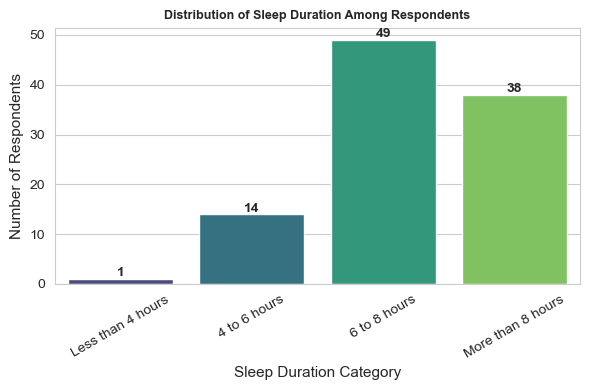

In [38]:
# Define desired order
order = ['Less than 4 hours','4 to 6 hours','6 to 8 hours','More than 8 hours']

# Get counts
sleep_duration_counts = ( sleep_and_mood_df['Sleep_Duration'].value_counts().reindex(order, fill_value=0)
)

# Set style
sns.set_style("whitegrid")

plt.figure(figsize=(6,4))

# Create barplot
ax = sns.barplot( x=sleep_duration_counts.index, y=sleep_duration_counts.values, palette="viridis" )

# Add value labels on bars
for i, value in enumerate(sleep_duration_counts.values):
    ax.text(i, value + 0.5, str(value), 
            ha='center', fontweight='bold')

plt.title('Distribution of Sleep Duration Among Respondents', fontsize=9, fontweight='bold')
plt.xlabel('Sleep Duration Category', fontsize=11)
plt.ylabel('Number of Respondents', fontsize=11)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

> <b><u>Analytical statement </u>:</b> The majority of respondents (49 participants) reported sleeping 6 to 8 hours, followed by 38 participants sleeping more than 8 hours. Only 14 respondents slept 4 to 6 hours, and very few (1 respondent) reported sleeping less than 4 hours.
This indicates that most individuals in the dataset maintain a healthy sleep duration, with very limited cases of extreme sleep deprivation.

#### Q32: How does Sleep Duration affect Mood Rating? - Bivariate Analysis (Two Variables)

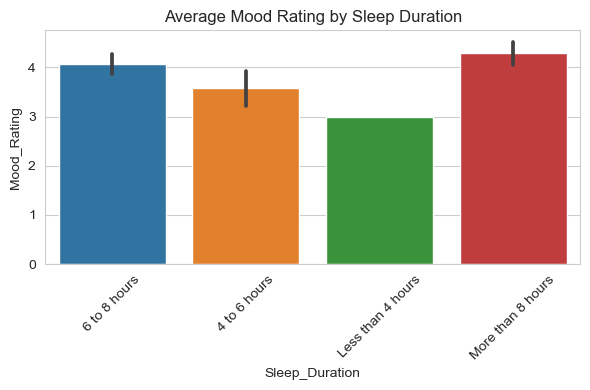

In [39]:
plt.figure(figsize=(6,4))

sns.barplot(
    x='Sleep_Duration',
    y='Mood_Rating',
    data=sleep_and_mood_df
)

plt.title('Average Mood Rating by Sleep Duration')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

> <b><u>Analytical statement </u>:</b> Mood rating increases with better sleep duration. Respondents who slept more than 8 hours reported the highest average mood rating (4.3), followed by those who slept 6 to 8 hours (4.0).
Participants sleeping less than 4 hours showed the lowest mood rating (3.0).
This suggests a positive relationship between sleep duration and mood, indicating that adequate sleep contributes to better emotional well-being.

#### Q33: What is the correlation between Sleep Hours, Mood Rating, Morning Refresh Score, and Sleep Quality Score? - Multivariate Analysis (Multiple Variables)

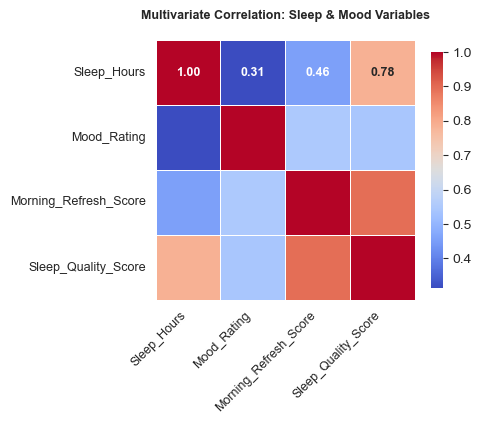

In [40]:
# Select required columns
corr_data = sleep_and_mood_df[ ['Sleep_Hours','Mood_Rating','Morning_Refresh_Score','Sleep_Quality_Score'] ]

# Compute correlation
correlation_matrix = corr_data.corr()

# Set style
sns.set_style("white")

plt.figure(figsize=(5,5))

heatmap = sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap= "coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.6},
    annot_kws={"size": 9, "weight": "bold"}
)

plt.title( "Multivariate Correlation: Sleep & Mood Variables", fontsize=9, fontweight='bold',pad=15 )

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)

plt.tight_layout()
plt.show()

> <b><u>Analytical statement </u>:</b> The heatmap reveals:
>- Strong positive correlation between Sleep Hours and Sleep Quality Score (0.78)
>- Moderate positive correlation between Sleep Hours and Morning Refresh Score (0.46)
>- Moderate positive correlation between Sleep Hours and Mood Rating (0.31)
>- Additionally, Morning Refresh Score and Sleep Quality Score show a strong positive relationship.
>- This indicates that longer sleep duration significantly improves sleep quality and refreshment levels, which in turn positively influences mood.

#### 34: Does High Screen Exposure before bed reduce Sleep Quality Score? - Behavioral Pattern Analysis

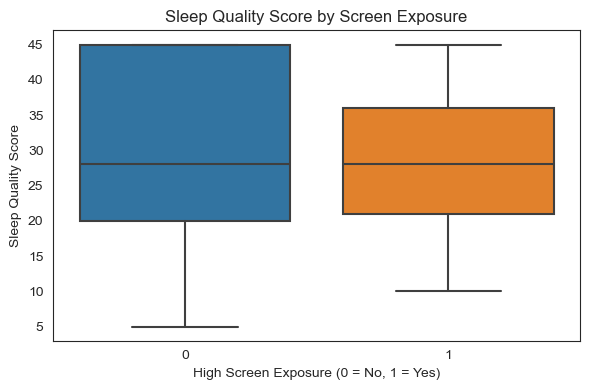

In [41]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x='High_Screen_Exposure',
    y='Sleep_Quality_Score',
    data=sleep_and_mood_df
)

plt.title('Sleep Quality Score by Screen Exposure')
plt.xlabel('High Screen Exposure (0 = No, 1 = Yes)')
plt.ylabel('Sleep Quality Score')

plt.tight_layout()
plt.show()

> <b><u>Analytical statement </u>:</b> The boxplot shows that individuals with high screen exposure before bedtime (1) tend to have slightly lower median sleep quality scores compared to those with low screen exposure (0).
>- There is also greater variability in sleep quality among high screen users.
>- This suggests that excessive screen exposure before sleep may negatively impact sleep quality.

#### 35: Which Bedtime Category is associated with the lowest Mood Rating? - Insight-Driven Visualization

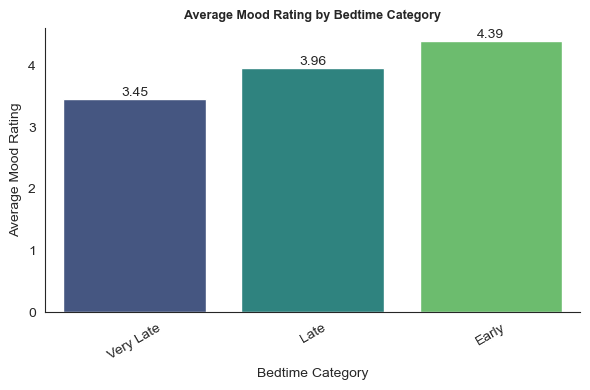

In [42]:
# Calculate mean mood rating per category and sort
bedtime_mood = ( sleep_and_mood_df.groupby('Bedtime_Category')['Mood_Rating'].mean().sort_values() )

plt.figure(figsize=(6,4))

# styling barplot
ax = sns.barplot( x=bedtime_mood.index, y=bedtime_mood.values, palette="viridis" )

# Add value labels on bars
for i, value in enumerate(bedtime_mood.values):
    plt.text(i, value + 0.05, f"{value:.2f}", ha='center')

plt.title('Average Mood Rating by Bedtime Category', fontsize=9, fontweight='bold')
plt.xlabel('Bedtime Category')
plt.ylabel('Average Mood Rating')
plt.xticks(rotation=30)

sns.despine()  # Clean look
plt.tight_layout()
plt.show()

> <b><u>Analytical statement </u>:</b> Participants who went to bed early reported the highest average mood rating (4.39), followed by those who slept late (3.96).
>- Those who went to bed very late had the lowest mood rating (~3.45).
>- This indicates that earlier bedtime habits are associated with better mood outcomes, reinforcing the importance of consistent sleep schedules.

#### 36: Which features most strongly influence Poor Sleep Hygiene? - Predictive Insight Visualization (Advanced)

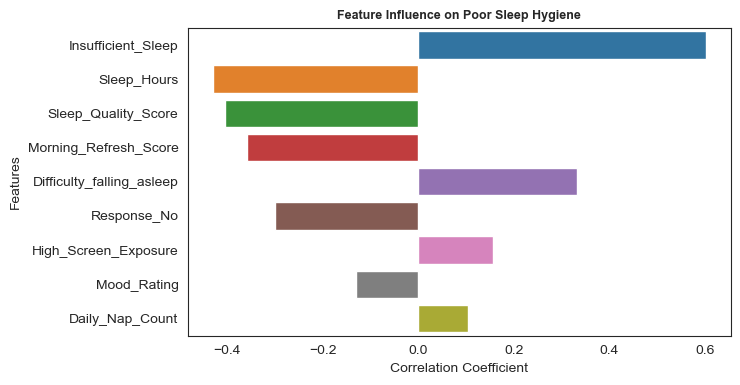

In [43]:
# Correlation directly
corr = final_df.corr(numeric_only=True)['Poor_Sleep_Hygiene']

# Remove self-correlation
corr = corr.drop('Poor_Sleep_Hygiene')

# Sort by absolute strength
corr = corr.reindex(corr.abs().sort_values(ascending=False).index)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,4))
sns.barplot(x=corr.values, y=corr.index)
plt.title('Feature Influence on Poor Sleep Hygiene', fontsize=9, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.show()

> <b><u>Analytical statement </u>:</b> The strongest positive correlation with poor sleep hygiene is Insufficient Sleep (0.60), followed by Difficulty Falling Asleep (0.33) and High Screen Exposure (0.18).
>- Negative correlations are observed with: Sleep Hours, Sleep Quality Score, Morning Refresh Score
>- This suggests that poor sleep hygiene is primarily driven by insufficient sleep and sleep difficulties, while higher sleep quality and adequate sleep duration reduce the likelihood of poor sleep hygiene.

### SECTION G: CONCLUSION

#### The analysis confirms that adequate sleep duration, early bedtime habits, and limited screen exposure significantly improve sleep quality and mood. Insufficient sleep and sleep difficulties are the strongest contributors to poor sleep hygiene.